# PCA on Pizza Composition Data

This notebook applies our custom `rice_Ml` PCA to a dataset of pizza nutritional content across different brands. We will:
1. Load and explore the data
2. Standardize the features
3. Fit our PCA and scikit‑learn's PCA (2 components)
4. Compare explained variance and principal components
5. Visualize the 2‑D projection (colored by brand)
6. Verify reconstruction and align signs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Custom PCA and scaler
from rice_Ml.unsupervised_ml.decomposition import PCA
from rice_Ml.preprocessing.scale import StandardScaler

# Scikit‑learn comparison
from sklearn.decomposition import PCA as SklearnPCA

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load the Dataset

In [2]:
df = pd.read_csv('pizza.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (300, 9)


,brand,id,mois,prot,fat,ash,sodium,carb,cal
0,A,14069,27.82,21.43,44.87,5.11,1.77,0.77,4.93
1,A,14053,28.49,21.26,43.89,5.34,1.79,1.02,4.84
2,A,14025,28.35,19.99,45.78,5.08,1.63,0.80,4.95
3,A,14016,30.55,20.15,43.13,4.79,1.61,1.38,4.74
4,A,14005,30.49,21.28,41.65,4.82,1.64,1.76,4.67


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
df.describe()

,id,mois,prot,fat,ash,sodium,carb,cal
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,20841.040000,40.903067,13.373567,20.229533,2.633233,0.669400,22.864767,3.271000
std,6962.917222,9.552987,6.434392,8.975658,1.269724,0.370358,18.029722,0.620034
min,14003.000000,25.000000,6.980000,4.380000,1.170000,0.250000,0.510000,2.180000
25%,14093.750000,30.902500,8.060000,14.770000,1.450000,0.450000,3.467500,2.910000
50%,24020.500000,43.300000,10.440000,17.135000,2.225000,0.490000,23.245000,3.215000
75%,24110.250000,49.115000,20.022500,21.435000,3.592500,0.702500,41.337500,3.520000
max,34045.000000,57.220000,28.480000,47.200000,5.430000,1.790000,48.640000,5.080000


In [4]:
# Check missing values
df.isnull().sum()

brand     0
id        0
mois      0
prot      0
fat       0
ash       0
sodium    0
carb      0
cal       0
dtype: int64

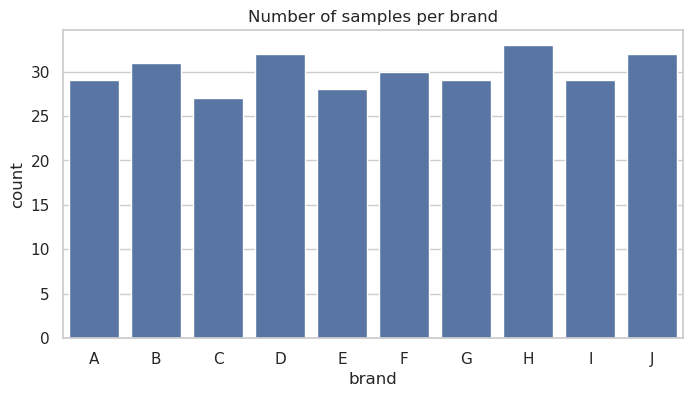

In [5]:
# Distribution of brands
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='brand', order=sorted(df['brand'].unique()))
plt.title('Number of samples per brand')
plt.show()

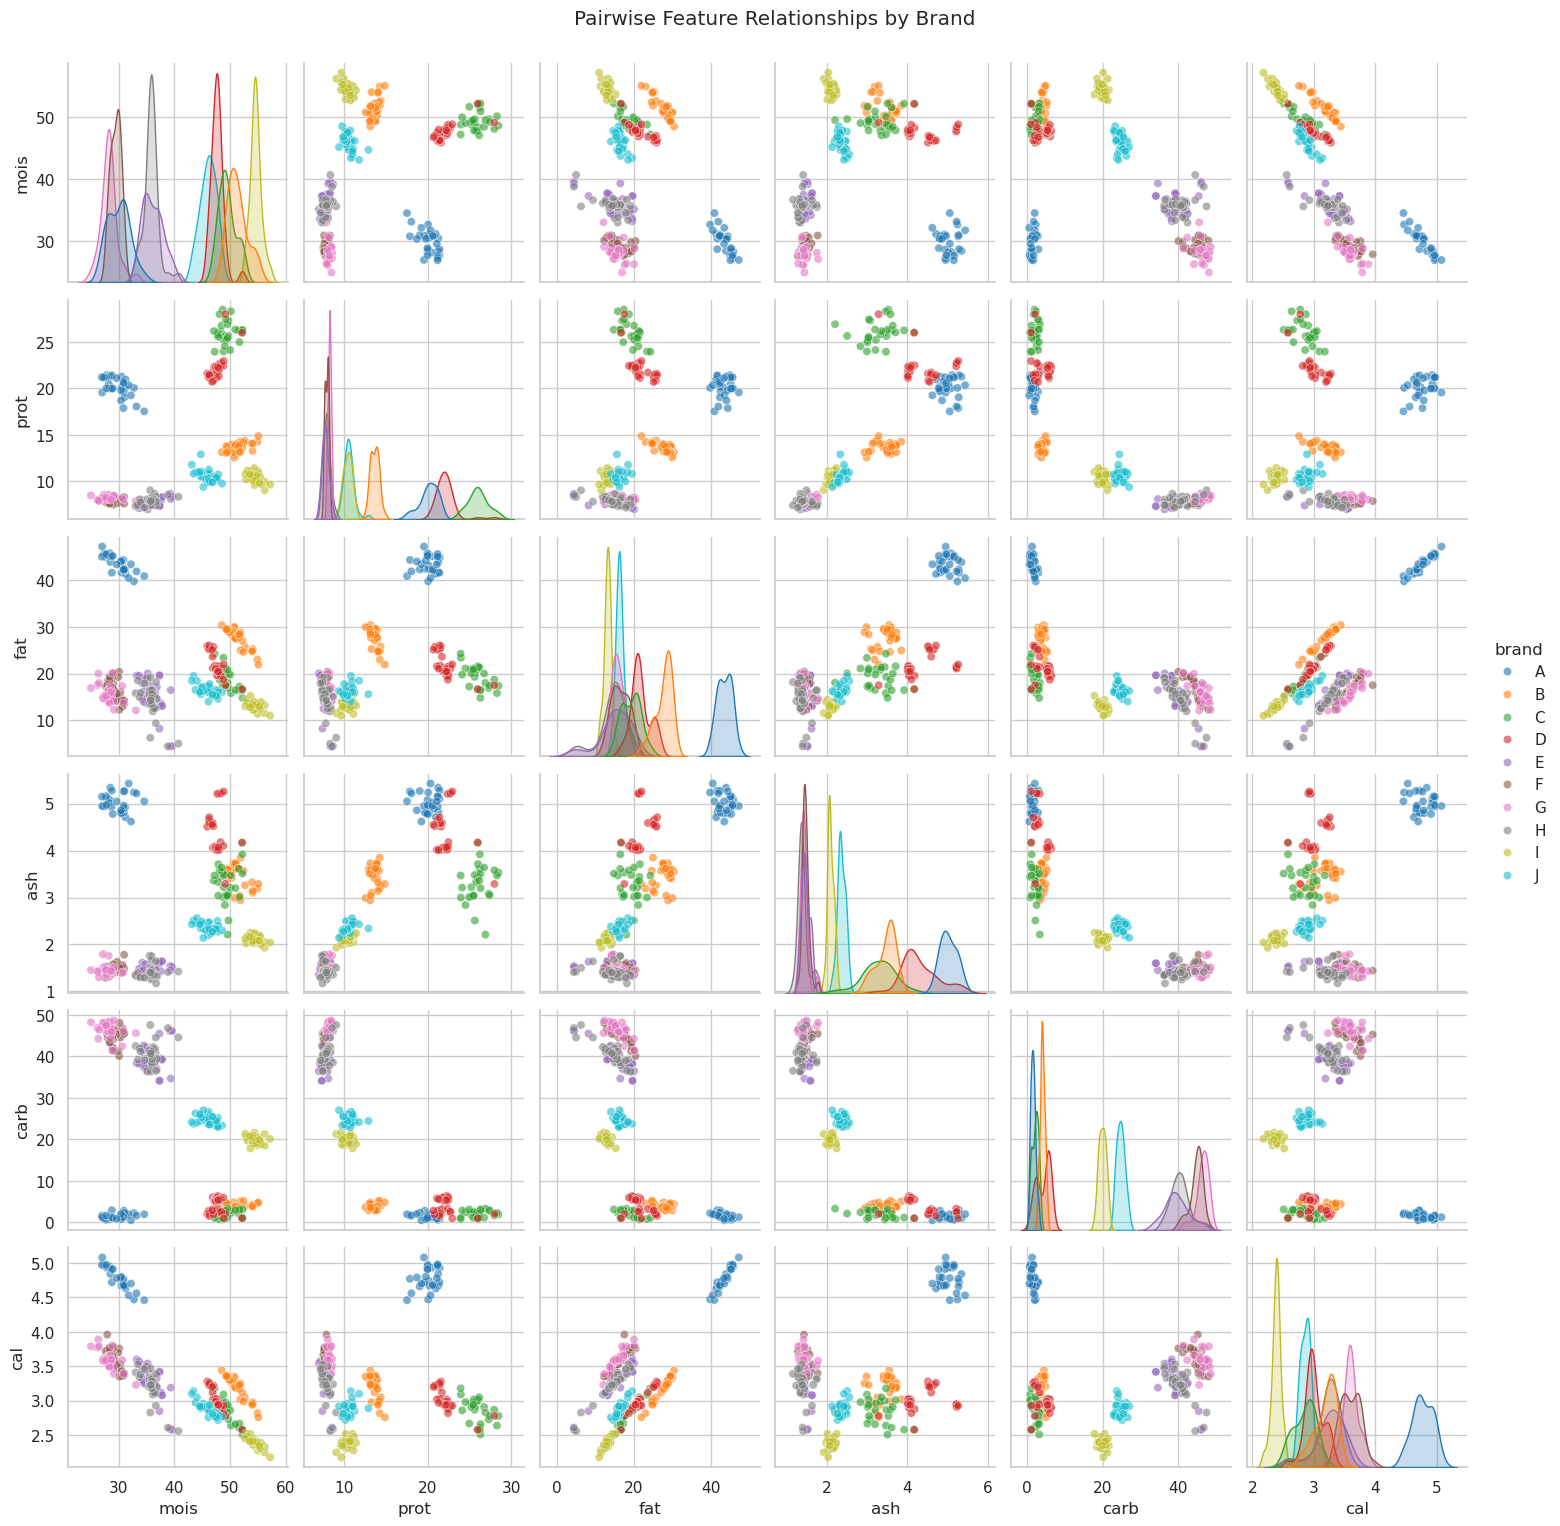

In [6]:
# Pairwise relationships (a few key features)
features = ['mois', 'prot', 'fat', 'ash', 'carb', 'cal']
sns.pairplot(df, vars=features, hue='brand', palette='tab10', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairwise Feature Relationships by Brand', y=1.02)
plt.show()

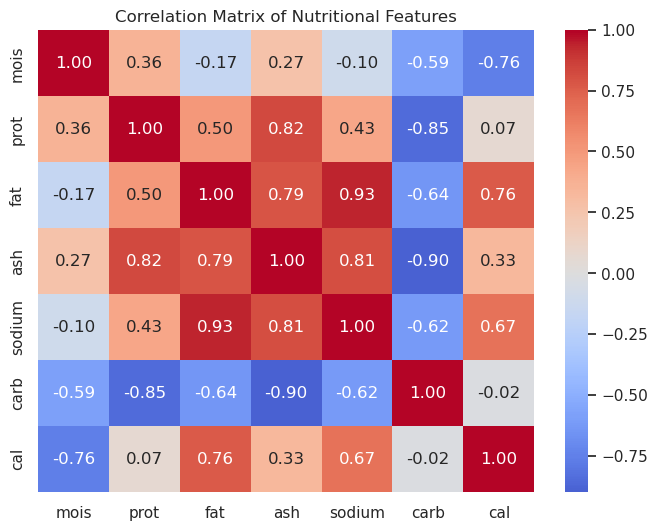

In [7]:
# Correlation heatmap of numerical features
plt.figure(figsize=(8,6))
numeric_cols = ['mois', 'prot', 'fat', 'ash', 'sodium', 'carb', 'cal']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Nutritional Features')
plt.show()

## 3. Prepare Data for PCA

We remove the identifier column `id` and the categorical column `brand` (used later for coloring). Then we standardize the nutritional features.

In [8]:
X = df.drop(columns=['brand', 'id']).values
brands = df['brand'].values
feature_labels = list(df.drop(columns=['brand', 'id']).columns)
print("Feature names:", feature_labels)

Feature names: ['mois', 'prot', 'fat', 'ash', 'sodium', 'carb', 'cal']


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling:", X_scaled.mean(axis=0).round(6))
print("Std after scaling:  ", X_scaled.std(axis=0).round(6))

Mean after scaling: [-0.  0. -0. -0. -0. -0.  0.]
Std after scaling:   [1. 1. 1. 1. 1. 1. 1.]


## 4. Fit PCA (2 Components) – Custom vs Scikit‑learn

In [10]:
# Custom PCA
pca_custom = PCA(n_components=2)
X_custom = pca_custom.fit_transform(X_scaled)

# Scikit‑learn PCA
pca_sk = SklearnPCA(n_components=2)
X_sk = pca_sk.fit_transform(X_scaled)

print("Custom explained variance ratio:", pca_custom.explained_variance_ratio_)
print("Sklearn explained variance ratio:", pca_sk.explained_variance_ratio_)
print("Cumulative (custom):", np.sum(pca_custom.explained_variance_ratio_))
print("Cumulative (sklearn):", np.sum(pca_sk.explained_variance_ratio_))

Custom explained variance ratio: [0.59796205 0.32830254]
Sklearn explained variance ratio: [0.59596884 0.3272082 ]
Cumulative (custom): 0.9262645892310575
Cumulative (sklearn): 0.9231770406002877


In [11]:
# Align signs for visual comparison
# Because eigenvectors can be flipped, we flip our components to match sklearn's orientation
signs = np.sign(np.diag(pca_custom.components_ @ pca_sk.components_.T))
X_custom_aligned = X_custom * signs

# Verify correlation between aligned components
for i in range(2):
    corr = np.corrcoef(X_custom_aligned[:, i], X_sk[:, i])[0, 1]
    print(f"PC{i+1} correlation (should be +1 or -1): {corr:.6f}")

PC1 correlation (should be +1 or -1): 1.000000
PC2 correlation (should be +1 or -1): 1.000000


## 5. 2‑D Scatter Plot by Brand

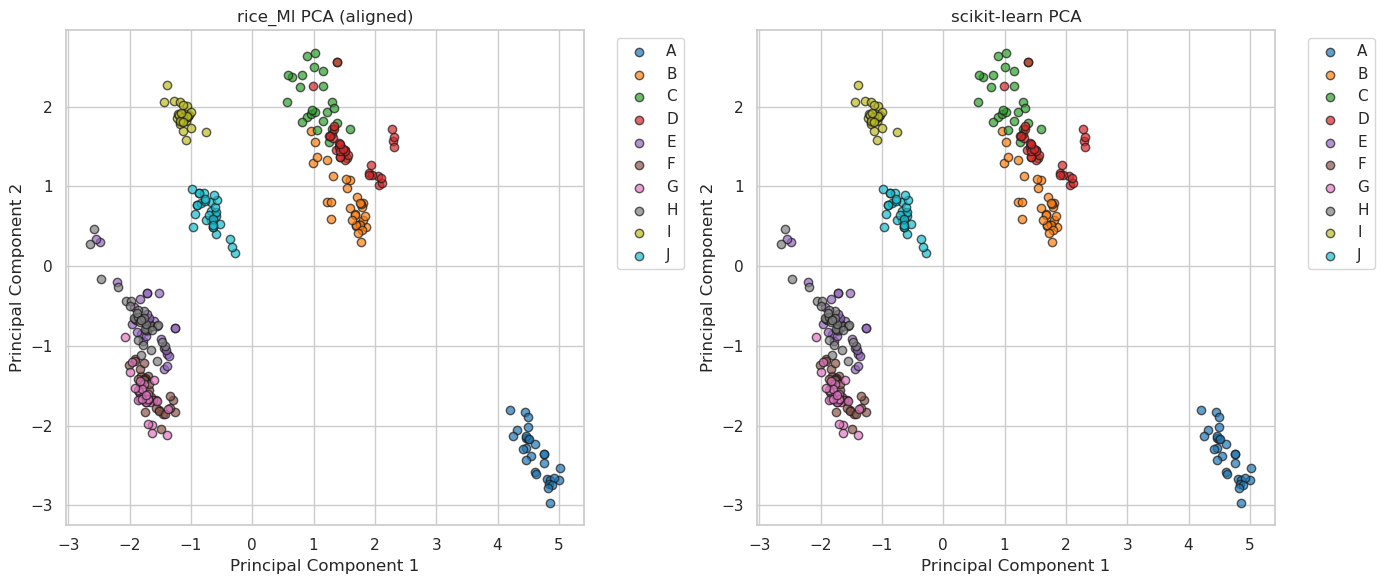

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
unique_brands = sorted(np.unique(brands))
palette = dict(zip(unique_brands, sns.color_palette('tab10', n_colors=len(unique_brands))))

for ax, X_plot, title in zip(
    axes,
    [X_custom_aligned, X_sk],
    ['rice_Ml PCA (aligned)', 'scikit‑learn PCA']
):
    for brand in unique_brands:
        mask = brands == brand
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   c=[palette[brand]], label=brand, edgecolor='k', alpha=0.7)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 6. Component Loadings (How Original Features Contribute)

We show the weights of each feature in the principal components (custom, after sign alignment).

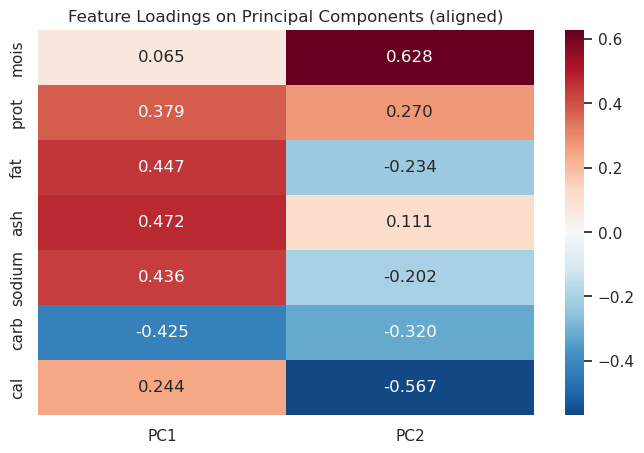

In [13]:
# Multiply components by the sign to align (since we flipped the scores, components also flip)
components_aligned = pca_custom.components_ * signs[:, np.newaxis]
loadings = pd.DataFrame(
    components_aligned.T,
    index=feature_labels,
    columns=['PC1', 'PC2']
)

plt.figure(figsize=(8,5))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.3f')
plt.title('Feature Loadings on Principal Components (aligned)')
plt.show()

## 7. Reconstruction Error

We measure how much information is lost by projecting onto 2 components.

In [14]:
X_recon = pca_custom.inverse_transform(X_custom)
recon_error = np.mean((X_scaled - X_recon) ** 2)
print(f"Mean squared reconstruction error (custom): {recon_error:.6f}")

X_sk_recon = pca_sk.inverse_transform(X_sk)
sk_error = np.mean((X_scaled - X_sk_recon) ** 2)
print(f"Mean squared reconstruction error (sklearn): {sk_error:.6f}")

Mean squared reconstruction error (custom): 0.076823
Mean squared reconstruction error (sklearn): 0.076823


## 8. Scree Plot

Explained variance by all principal components.

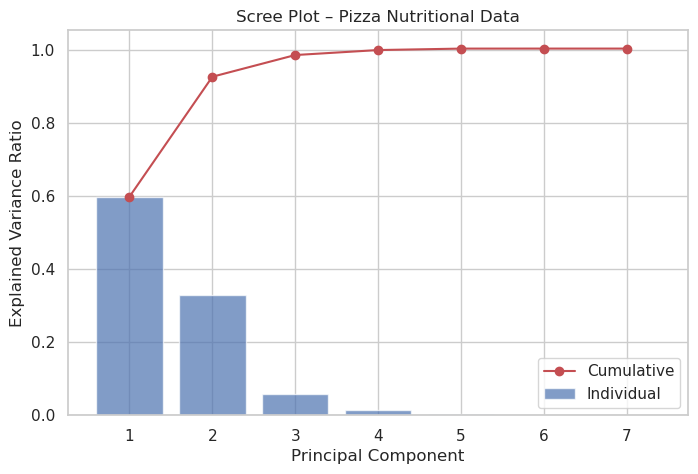

In [15]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))
components = np.arange(1, len(pca_full.explained_variance_ratio_)+1)
plt.bar(components, pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.plot(components, np.cumsum(pca_full.explained_variance_ratio_), 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot – Pizza Nutritional Data')
plt.legend()
plt.show()

## Summary

- The pairplot and correlation heatmap show strong relationships between moisture, protein, fat, and carbs.
- PCA captures most variance in the first two components (see scree plot).
- Our custom PCA produces the same explained variance ratios and reconstruction error as scikit‑learn.
- After sign alignment, the 2‑D scores are identical (correlation ±1).
- The PCA projection reveals distinct clusters of brands, e.g., brand I appears well separated from others.

This demonstrates the correct functionality of `rice_Ml.unsupervised_ml.decomposition.PCA` on a real-world multi‑feature dataset.